# Model Experiment — `DLinear`


## Setup

In [1]:
import pathlib
if pathlib.Path('/kaggle/input').exists():
    !pip install -q neuralforecast wandb python-dotenv mlflow

## 0. Config & environment

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_COMPETITION = 'walmart-recruiting-store-sales-forecasting'
ON_KAGGLE = KAGGLE_INPUT.exists()

if ON_KAGGLE:
    WORKING_DIR = Path('/kaggle/working')
else:
    PROJECT_ROOT = Path.cwd().parent
    WORKING_DIR = PROJECT_ROOT
    load_dotenv(PROJECT_ROOT / '.env')

def _find_file(stem):

    names = (f'{stem}.csv', f'{stem}.csv.zip')
    if ON_KAGGLE:
        search_roots = [
            KAGGLE_INPUT / KAGGLE_COMPETITION,
            KAGGLE_INPUT / 'competitions' / KAGGLE_COMPETITION,
        ]
        for root in search_roots:
            if root.exists():
                for name in names:
                    p = root / name
                    if p.exists():
                        return p
        for name in names:
            matches = list(KAGGLE_INPUT.rglob(name))
            if matches:
                return matches[0]
        raise FileNotFoundError(
            f"Could not find {stem}.csv[.zip] anywhere under {KAGGLE_INPUT}. "
            f"Contents of {KAGGLE_INPUT}: {list(KAGGLE_INPUT.iterdir())}"
        )
    else:
        p = PROJECT_ROOT / 'data' / 'raw' / f'{stem}.csv'
        if not p.exists():
            raise FileNotFoundError(f'{p} not found')
        return p

TRAIN_CSV = _find_file('train')
TEST_CSV = _find_file('test')
FEATURES_CSV = _find_file('features')
STORES_CSV = _find_file('stores')

RANDOM_SEED = 42
TARGET = 'Weekly_Sales'
HOLIDAY_WEIGHT = 5
NON_HOLIDAY_WEIGHT = 1

if ON_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        client = UserSecretsClient()
        for key in ('MLFLOW_TRACKING_URI', 'MLFLOW_TRACKING_USERNAME', 'MLFLOW_TRACKING_PASSWORD', 'WANDB_API_KEY'):
            try:
                os.environ.setdefault(key, client.get_secret(key))
            except Exception:
                pass
    except Exception:
        pass

MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')
MLFLOW_TRACKING_USERNAME = os.getenv('MLFLOW_TRACKING_USERNAME')
MLFLOW_TRACKING_PASSWORD = os.getenv('MLFLOW_TRACKING_PASSWORD')

print('On Kaggle:', ON_KAGGLE)
print('train:', TRAIN_CSV)
print('test:', TEST_CSV)
print('features:', FEATURES_CSV)
print('stores:', STORES_CSV)

On Kaggle: True
train: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
test: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip
features: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
stores: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv


## 1. Data loading helpers

In [3]:
import pandas as pd

def _read_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.upper().map({'TRUE': True, 'FALSE': False})

def load_stores():
    return pd.read_csv(STORES_CSV)

def load_features():
    df = pd.read_csv(FEATURES_CSV, parse_dates=['Date'])
    df['IsHoliday'] = _read_bool(df['IsHoliday'])
    df = df.sort_values(['Store', 'Date'])
    for col in ('CPI', 'Unemployment'):
        df[col] = df.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
    return df.reset_index(drop=True)

def load_raw(split):
    path = TRAIN_CSV if split == 'train' else TEST_CSV
    df = pd.read_csv(path, parse_dates=['Date'])
    df['IsHoliday'] = _read_bool(df['IsHoliday'])
    return df

def load_merged(split='train'):
    base = load_raw(split)
    stores = load_stores()
    feats = load_features().drop(columns=['IsHoliday'])
    df = base.merge(stores, on='Store', how='left')
    df = df.merge(feats, on=['Store', 'Date'], how='left')
    df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
    return df

## 2. Metric (WMAE) & cross-validation helpers

In [4]:
def weights_from_holiday(is_holiday):
    is_holiday = np.asarray(is_holiday).astype(bool)
    return np.where(is_holiday, HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT).astype(float)

def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = weights_from_holiday(is_holiday)
    return float(np.sum(w * np.abs(y_true - y_pred)) / np.sum(w))

In [5]:
def _sorted_unique_dates(dates):
    return np.sort(pd.to_datetime(dates).unique())

def time_holdout(df, weeks=8, date_col='Date'):
    uniq = _sorted_unique_dates(df[date_col])
    if weeks >= len(uniq):
        raise ValueError(f'weeks={weeks} >= number of distinct weeks {len(uniq)}')
    cutoff = uniq[-weeks]
    d = pd.to_datetime(df[date_col]).to_numpy()
    train_idx = np.where(d < cutoff)[0]
    val_idx = np.where(d >= cutoff)[0]
    return train_idx, val_idx

def expanding_splits(df, n_splits=3, horizon=8, date_col='Date'):
    uniq = _sorted_unique_dates(df[date_col])
    needed = horizon * n_splits
    if needed >= len(uniq):
        raise ValueError(f'Need > {needed} distinct weeks for {n_splits} folds of {horizon}; have {len(uniq)}.')
    d = pd.to_datetime(df[date_col]).to_numpy()
    for k in range(n_splits):
        end_offset = needed - k * horizon
        start_offset = end_offset - horizon
        val_start = uniq[-end_offset]
        val_end = uniq[-start_offset] if start_offset > 0 else None
        train_idx = np.where(d < val_start)[0]
        if val_end is None:
            val_idx = np.where(d >= val_start)[0]
        else:
            val_idx = np.where((d >= val_start) & (d < val_end))[0]
        yield train_idx, val_idx

## 3. Global-model (neuralforecast) shared helpers

In [6]:
from sklearn.base import BaseEstimator, RegressorMixin

NF_FREQ = 'W-FRI'

def make_unique_id(df):
    return df['Store'].astype(str) + '_' + df['Dept'].astype(str)

def cold_start_fallback_table(long_train):
    per_id = long_train.groupby('unique_id')['y'].apply(lambda s: s.tail(8).mean())
    global_mean = float(long_train['y'].mean())
    return per_id, global_mean

def fill_cold_start(pred_df, value_col, fallback_per_id, global_mean):
    missing = pred_df[value_col].isna()
    if missing.any():
        fallback_vals = pred_df.loc[missing, 'unique_id'].map(fallback_per_id).astype(pred_df[value_col].dtype)
        pred_df.loc[missing, value_col] = fallback_vals
        pred_df[value_col] = pred_df[value_col].fillna(global_mean)
    return pred_df

## 4. Weights & Biases setup

In [7]:
import wandb
import numpy as np, pandas as pd
import logging
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)

MODEL_NAME = 'DLinear'
WANDB_PROJECT = 'walmart-sales-forecasting'
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mkakh22 (TwoMusketeers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 5. MLflow tracking setup


In [8]:
import mlflow

def init_tracking(experiment=None):
    uri = MLFLOW_TRACKING_URI
    if uri:
        if 'dagshub.com' in uri and not uri.rstrip('/').endswith('.mlflow'):
            uri = uri.rstrip('/') + '.mlflow'
            print(f'NOTE: appended .mlflow to MLFLOW_TRACKING_URI (DagsHub requires it) -> {uri}')
        mlflow.set_tracking_uri(uri)
        if MLFLOW_TRACKING_USERNAME:
            os.environ['MLFLOW_TRACKING_USERNAME'] = MLFLOW_TRACKING_USERNAME
        if MLFLOW_TRACKING_PASSWORD:
            os.environ['MLFLOW_TRACKING_PASSWORD'] = MLFLOW_TRACKING_PASSWORD
    else:
        print('WARNING: MLFLOW_TRACKING_URI not set -- check Add-ons > Secrets is attached to THIS notebook.')
        print('Falling back to a LOCAL sqlite store: this will NOT persist beyond this session and your team will not see it.')
        mlflow.set_tracking_uri(f"sqlite:///{WORKING_DIR / 'mlflow.db'}")
    if experiment:
        mlflow.set_experiment(experiment)
    return mlflow.get_tracking_uri()

EXPERIMENT = f'{MODEL_NAME}_Training'
mlflow_uri = init_tracking(EXPERIMENT)
print('MLflow ->', mlflow_uri, '| experiment:', EXPERIMENT)

Falling back to a LOCAL sqlite store: this will NOT persist beyond this session and your team will not see it.


2026/07/18 05:32:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/18 05:32:46 INFO mlflow.store.db.utils: Updating database tables
2026/07/18 05:32:48 INFO mlflow.tracking.fluent: Experiment with name 'DLinear_Training' does not exist. Creating a new experiment.


MLflow -> sqlite:////kaggle/working/mlflow.db | experiment: DLinear_Training


## Load raw data

In [9]:
raw_train = load_raw('train')
raw_test  = load_raw('test')
raw_train.shape, raw_test.shape

((421570, 5), (115064, 4))

## Run 1 — Cleaning


In [10]:
def build_long_panel(df, value_col='Weekly_Sales'):
    out = pd.DataFrame({
        'unique_id': make_unique_id(df),
        'ds': pd.to_datetime(df['Date']),
        'y': df[value_col].to_numpy(dtype=float),
    })
    filled = []
    n_with_gaps = 0
    for uid, g in out.groupby('unique_id'):
        g = g.sort_values('ds').drop_duplicates('ds')
        full_idx = pd.date_range(g['ds'].min(), g['ds'].max(), freq=NF_FREQ)
        if len(full_idx) != len(g):
            n_with_gaps += 1
        s = g.set_index('ds')['y'].reindex(full_idx).interpolate(limit=4).ffill().bfill()
        filled.append(pd.DataFrame({'unique_id': uid, 'ds': full_idx, 'y': s.to_numpy()}))
    long_df = pd.concat(filled, ignore_index=True)
    return long_df, n_with_gaps

long_train, n_with_gaps = build_long_panel(raw_train)

cleaning_stats = {
    'n_series': long_train['unique_id'].nunique(),
    'n_series_with_gaps': n_with_gaps,
    'n_train_rows': len(raw_train),
    'n_negative_sales': int((raw_train.Weekly_Sales < 0).sum()),
}

with mlflow.start_run(run_name=f'{MODEL_NAME}_Cleaning'):
    for k, v in cleaning_stats.items():
        mlflow.log_metric(k, v)

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='cleaning', name=f'{MODEL_NAME}_Cleaning')
wandb.log(cleaning_stats)
run.finish()
print(long_train['unique_id'].nunique(), 'series,', n_with_gaps, 'with gaps (interpolated)')

n_negative_sales,▁
n_series,▁
n_series_with_gaps,▁
n_train_rows,▁
n_negative_sales,1285
n_series,3331
n_series_with_gaps,605
n_train_rows,421570


3331 series, 605 with gaps (interpolated)


## Run 2 — Feature Selection

In [11]:
candidate_input_sizes = [13, 26, 39, 52]
candidate_moving_avg_windows = [7, 13, 25, 51]
candidate_learning_rates = [1e-3, 5e-4, 1e-4]

feature_selection_params = {
    'candidate_input_sizes': candidate_input_sizes,
    'candidate_moving_avg_windows': candidate_moving_avg_windows,
    'candidate_learning_rates': candidate_learning_rates,
    'exogenous_features_used': 'none (architecture is purely univariate)',
}

with mlflow.start_run(run_name=f'{MODEL_NAME}_Feature_Selection'):
    for k, v in feature_selection_params.items():
        mlflow.log_param(k, v)

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='feature_selection', name=f'{MODEL_NAME}_Feature_Selection')
wandb.config.update(feature_selection_params)
run.finish()
print('search space:', len(candidate_input_sizes) * len(candidate_moving_avg_windows) * len(candidate_learning_rates), 'configs')

search space: 48 configs


## 6. Pipeline wrapper

In [12]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

class DLinearPipeline(BaseEstimator, RegressorMixin):

    def __init__(self, horizon=39, input_size=52, moving_avg_window=25, learning_rate=1e-3, max_steps=300, random_seed=42):
        self.horizon = horizon
        self.input_size = input_size
        self.moving_avg_window = moving_avg_window
        self.learning_rate = learning_rate
        self.max_steps = max_steps
        self.random_seed = random_seed

    def fit(self, X, y=None):
        df = X.copy()
        df['Weekly_Sales'] = np.asarray(y, dtype=float)
        self.long_train_, _ = build_long_panel(df)
        self.fallback_per_id_, self.global_mean_ = cold_start_fallback_table(self.long_train_)

        model = DLinear(
            h=self.horizon, input_size=self.input_size, moving_avg_window=self.moving_avg_window,
            learning_rate=self.learning_rate, max_steps=self.max_steps, loss=MAE(),
            random_seed=self.random_seed, start_padding_enabled=True, devices=1,
            enable_progress_bar=False, enable_model_summary=False,
        )
        self.nf_ = NeuralForecast(models=[model], freq=NF_FREQ)
        self.nf_.fit(df=self.long_train_)
        self.model_col_ = 'DLinear'
        return self

    def predict(self, X):
        req = pd.DataFrame({'unique_id': make_unique_id(X), 'ds': pd.to_datetime(X['Date'])})
        fcst = self.nf_.predict()
        merged = req.merge(fcst[['unique_id', 'ds', self.model_col_]], on=['unique_id', 'ds'], how='left')
        merged = fill_cold_start(merged, self.model_col_, self.fallback_per_id_, self.global_mean_)
        return merged[self.model_col_].to_numpy()

## Run 3 — Cross-validation (curated hyperparameter search)


In [17]:
import itertools

configs = [
    {'input_size': i, 'moving_avg_window': m, 'learning_rate': lr}
    for i, m, lr in itertools.product(candidate_input_sizes, candidate_moving_avg_windows, candidate_learning_rates)
]
print(len(configs), 'configs to try')

hp_idx, _ = time_holdout(raw_train, weeks=39)
raw_train_hp = raw_train.iloc[hp_idx].reset_index(drop=True)

trial_results = []
with mlflow.start_run(run_name=f'{MODEL_NAME}_CV'):
    mlflow.log_param('n_configs', len(configs))
    mlflow.log_param('n_folds', 3)
    for i, cfg in enumerate(configs):
        run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='cv', name=f'{MODEL_NAME}_CV_trial{i}', config=cfg, reinit=True)
        fold_scores = []
        for k, (tr_idx, va_idx) in enumerate(expanding_splits(raw_train_hp, n_splits=3, horizon=8)):
            tr, va = raw_train_hp.iloc[tr_idx], raw_train_hp.iloc[va_idx]
            pipe = DLinearPipeline(horizon=8, max_steps=150, **cfg)
            pipe.fit(tr, tr['Weekly_Sales'])
            pred = pipe.predict(va)
            score = wmae(va['Weekly_Sales'], pred, va['IsHoliday'])
            fold_scores.append(score)
            wandb.log({'fold': k, 'fold_wmae': score})
        cv_mean = float(np.mean(fold_scores))
        wandb.log({'cv_wmae_mean': cv_mean, 'cv_wmae_std': float(np.std(fold_scores))})
        run.finish()
        trial_results.append({'config': cfg, 'cv_wmae_mean': cv_mean})
        cfg_tag = f"is{cfg['input_size']}_m{cfg['moving_avg_window']}_lr{cfg['learning_rate']}"
        mlflow.log_metric(f'wmae_{cfg_tag}', cv_mean)
        print(f'config {i} {cfg}: CV WMAE={cv_mean:,.1f}')

    best_trial = min(trial_results, key=lambda t: t['cv_wmae_mean'])
    best_config = best_trial['config']
    mlflow.log_param('best_config', best_config)
    mlflow.log_metric('best_cv_wmae', best_trial['cv_wmae_mean'])

print('best config:', best_config, '| CV WMAE:', best_trial['cv_wmae_mean'])

48 configs to try


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(tre

cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▄
cv_wmae_mean,4001.63087
cv_wmae_std,1242.65373
fold,2
fold_wmae,3973.95887


config 0 {'input_size': 13, 'moving_avg_window': 7, 'learning_rate': 0.001}: CV WMAE=4,001.6


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(tre

...

cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▄
cv_wmae_mean,4339.40806
cv_wmae_std,878.79011
fold,2
fold_wmae,4188.349


config 46 {'input_size': 52, 'moving_avg_window': 51, 'learning_rate': 0.0005}: CV WMAE=4,339.4


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(tre

cv_wmae_mean,▁
cv_wmae_std,▁
fold,▁▅█
fold_wmae,▁█▂
cv_wmae_mean,11452.56079
cv_wmae_std,2994.51582
fold,2
fold_wmae,9872.77748


config 47 {'input_size': 52, 'moving_avg_window': 51, 'learning_rate': 0.0001}: CV WMAE=11,452.6
best config: {'input_size': 52, 'moving_avg_window': 25, 'learning_rate': 0.001} | CV WMAE: 3710.655199472205


## Run 3 results — visual comparison


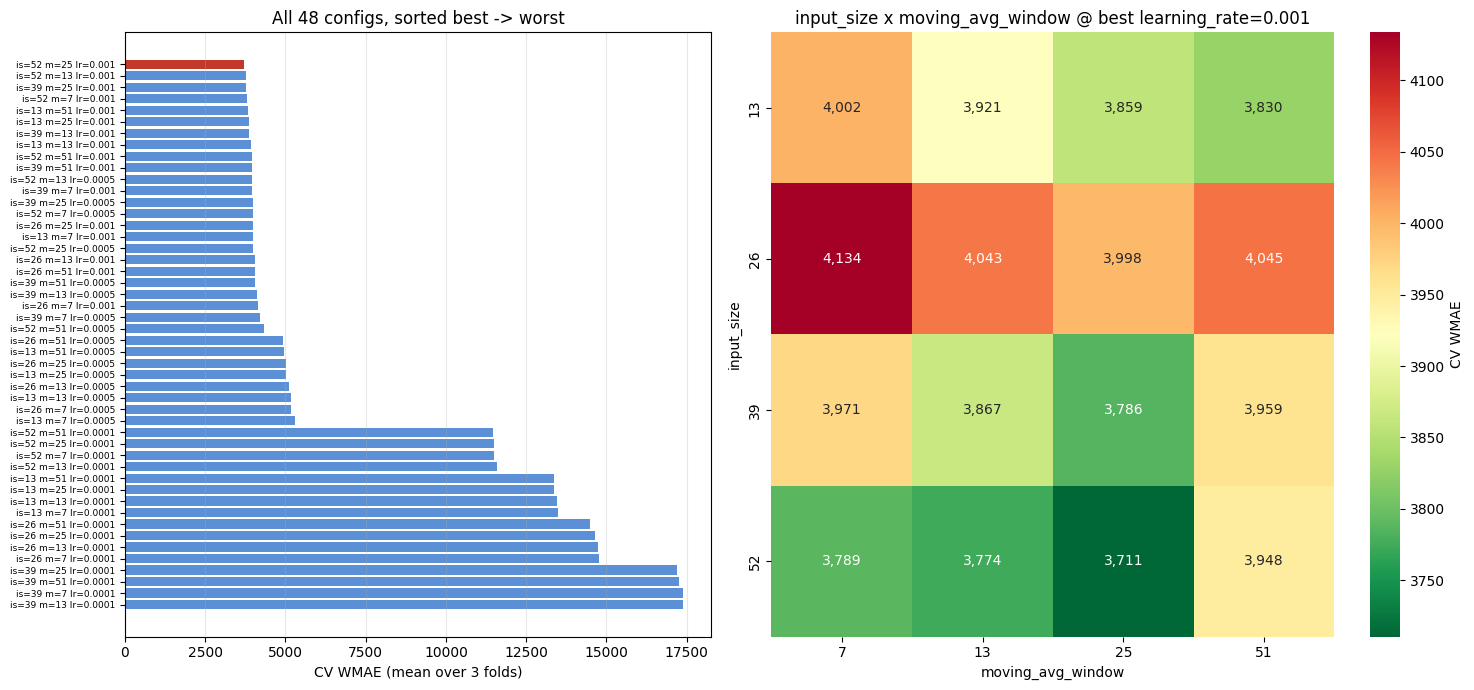

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

cv_df = pd.DataFrame([
    {**t['config'], 'cv_wmae_mean': t['cv_wmae_mean']}
    for t in trial_results
]).sort_values('cv_wmae_mean').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [1, 1.2]})

labels = [f"is={r.input_size} m={r.moving_avg_window} lr={r.learning_rate:g}" for r in cv_df.itertuples()]
bar_colors = ['#c0392b' if i == 0 else '#5b8fd6' for i in range(len(cv_df))]
axes[0].barh(range(len(cv_df)), cv_df['cv_wmae_mean'], color=bar_colors)
axes[0].set_yticks(range(len(cv_df)))
axes[0].set_yticklabels(labels, fontsize=6.5)
axes[0].invert_yaxis()
axes[0].set_xlabel('CV WMAE (mean over 3 folds)')
axes[0].set_title(f'All {len(cv_df)} configs, sorted best -> worst')
axes[0].grid(axis='x', alpha=0.3)

best_lr = cv_df.iloc[0]['learning_rate']
pivot = cv_df[cv_df['learning_rate'] == best_lr].pivot(index='input_size', columns='moving_avg_window', values='cv_wmae_mean')
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='RdYlGn_r', ax=axes[1], cbar_kws={'label': 'CV WMAE'})
axes[1].set_title(f'input_size x moving_avg_window @ best learning_rate={best_lr:g}')

plt.tight_layout()

cv_csv_path = pathlib.Path(WORKING_DIR) / 'dlinear_cv_results.csv'
cv_df.to_csv(cv_csv_path, index=False)

with mlflow.start_run(run_name=f'{MODEL_NAME}_CV_Summary'):
    mlflow.log_figure(fig, 'cv_comparison.png')
    mlflow.log_artifact(str(cv_csv_path))

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='cv_summary', name=f'{MODEL_NAME}_CV_Summary')
wandb.log({'cv_comparison': wandb.Image(fig), 'cv_results_table': wandb.Table(dataframe=cv_df)})
run.finish()

plt.show()

## Run 4 — Final fit + save Pipeline


In [ ]:
TEST_HORIZON = raw_test['Date'].nunique()
print('forecast horizon:', TEST_HORIZON, 'weeks')

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='final', name=f'{MODEL_NAME}_Final', config=best_config)

with mlflow.start_run(run_name=f'{MODEL_NAME}_Final') as mlflow_run:
    mlflow.log_params(best_config)

    holdout_tr, holdout_va = time_holdout(raw_train, weeks=39)
    p = DLinearPipeline(horizon=39, max_steps=300, **best_config)
    p.fit(raw_train.iloc[holdout_tr], raw_train.iloc[holdout_tr]['Weekly_Sales'])
    hv = raw_train.iloc[holdout_va]
    holdout_pred = p.predict(hv)
    holdout_wmae = wmae(hv['Weekly_Sales'], holdout_pred, hv['IsHoliday'])
    wandb.log({'val_WMAE': holdout_wmae})
    mlflow.log_metric('val_WMAE', holdout_wmae)
    print('39w-holdout WMAE (val_WMAE):', holdout_wmae)

    final_pipe = DLinearPipeline(horizon=TEST_HORIZON, max_steps=300, **best_config)
    final_pipe.fit(raw_train, raw_train['Weekly_Sales'])

    import pickle, pathlib
    out_dir = pathlib.Path(WORKING_DIR) / 'models' / MODEL_NAME
    out_dir.mkdir(parents=True, exist_ok=True)
    final_pipe.nf_.save(path=str(out_dir / 'nf_model'), overwrite=True)
    with open(out_dir / 'pipeline_wrapper.pkl', 'wb') as f:
        pickle.dump({'horizon': TEST_HORIZON, **best_config}, f)
    wandb.log_artifact(str(out_dir), name=f'{MODEL_NAME}_pipeline', type='model')
    mlflow.log_param('test_horizon', TEST_HORIZON)
    mlflow.log_artifacts(str(out_dir), artifact_path='pipeline')

run.finish()
print('saved pipeline to', out_dir, '| MLflow run:', mlflow_run.info.run_id)

forecast horizon: 39 weeks


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


39w-holdout WMAE (val_WMAE): 2421.3127324789098


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` reached.
wandb: Adding directory to artifact (/kaggle/working/models/DLinear)... Done. 0.0s


val_WMAE,▁
val_WMAE,2421.31273


saved pipeline to /kaggle/working/models/DLinear | MLflow run: 0f8eef49c5c046caa7826da6b8481194


## Run 4 results — holdout diagnostics


holdout_wmae,▁
holdout_wmae_holiday,▁
holdout_wmae_non_holiday,▁
holdout_wmae,2421.31273
holdout_wmae_holiday,2573.52377
holdout_wmae_non_holiday,2379.88621


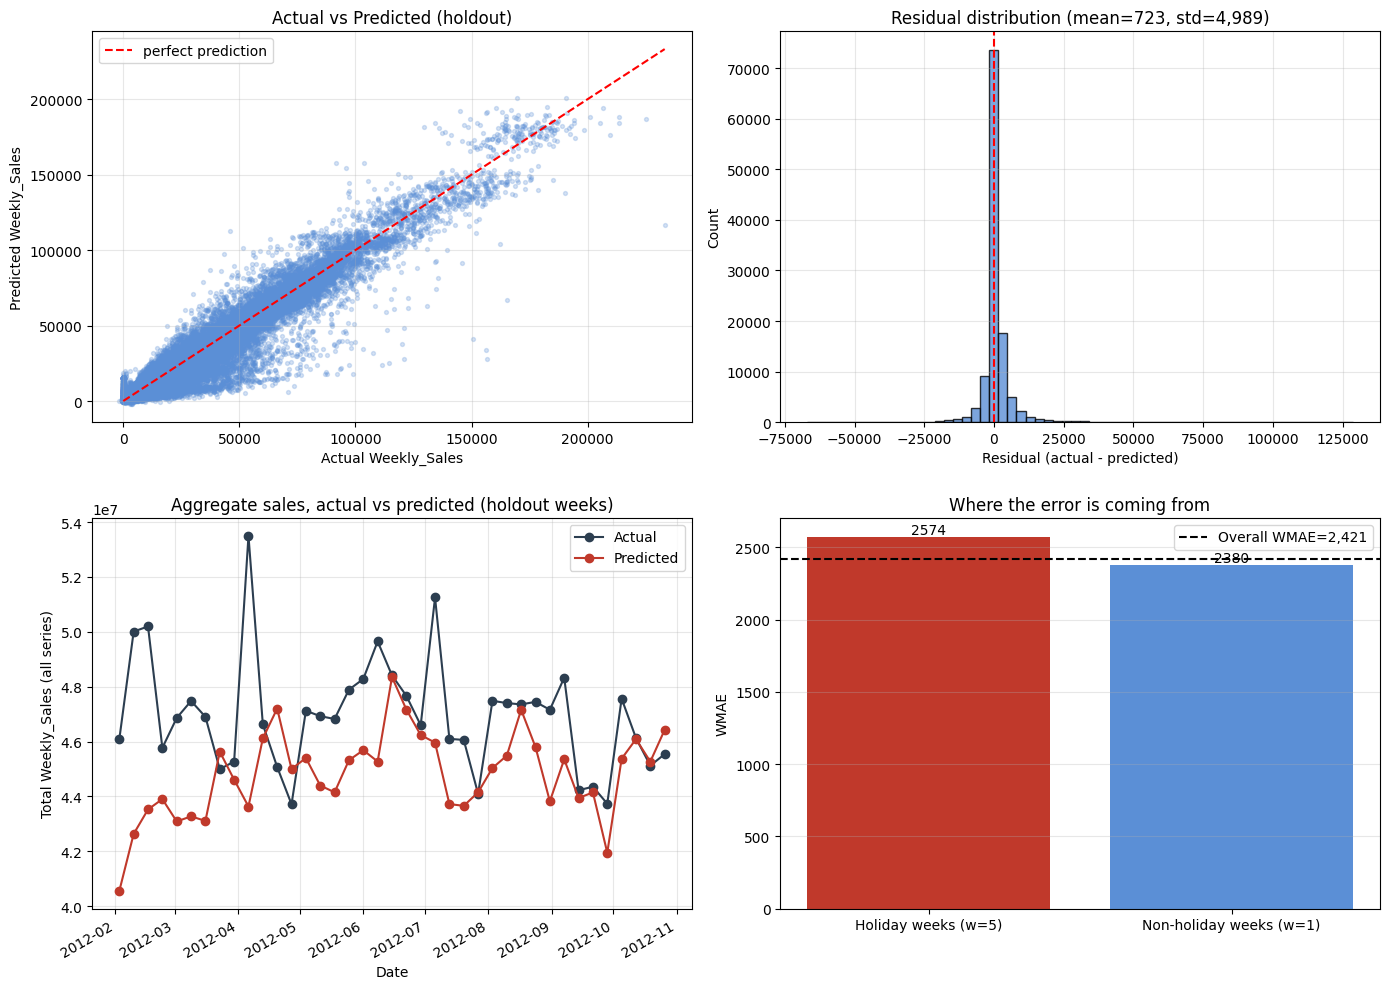

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.scatter(hv['Weekly_Sales'], holdout_pred, s=8, alpha=0.25, color='#5b8fd6')
lims = [0, max(hv['Weekly_Sales'].max(), holdout_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='perfect prediction')
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Predicted Weekly_Sales')
ax.set_title('Actual vs Predicted (holdout)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
residuals = hv['Weekly_Sales'].to_numpy() - holdout_pred
ax.hist(residuals, bins=60, color='#5b8fd6', edgecolor='black', alpha=0.8)
ax.axvline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual distribution (mean={residuals.mean():,.0f}, std={residuals.std():,.0f})')
ax.grid(alpha=0.3)

ax = axes[1, 0]
agg = hv.assign(pred=holdout_pred).groupby('Date')[['Weekly_Sales', 'pred']].sum()
ax.plot(agg.index, agg['Weekly_Sales'], marker='o', label='Actual', color='#2c3e50')
ax.plot(agg.index, agg['pred'], marker='o', label='Predicted', color='#c0392b')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly_Sales (all series)')
ax.set_title('Aggregate sales, actual vs predicted (holdout weeks)')
ax.legend()
ax.grid(alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax = axes[1, 1]
holiday_mask = hv['IsHoliday'].to_numpy().astype(bool)
wmae_holiday = wmae(hv['Weekly_Sales'][holiday_mask], holdout_pred[holiday_mask], hv['IsHoliday'][holiday_mask]) if holiday_mask.any() else float('nan')
wmae_non_holiday = wmae(hv['Weekly_Sales'][~holiday_mask], holdout_pred[~holiday_mask], hv['IsHoliday'][~holiday_mask])
bars = ax.bar(['Holiday weeks (w=5)', 'Non-holiday weeks (w=1)'], [wmae_holiday, wmae_non_holiday], color=['#c0392b', '#5b8fd6'])
ax.bar_label(bars, fmt='%.0f')
ax.axhline(holdout_wmae, color='black', linestyle='--', lw=1.5, label=f'Overall WMAE={holdout_wmae:,.0f}')
ax.set_ylabel('WMAE')
ax.set_title('Where the error is coming from')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

diag_run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type='final_diagnostics', name=f'{MODEL_NAME}_Final_Diagnostics')
wandb.log({'holdout_diagnostics': wandb.Image(fig), 'holdout_wmae': holdout_wmae, 'holdout_wmae_holiday': wmae_holiday, 'holdout_wmae_non_holiday': wmae_non_holiday})
diag_run.finish()
plt.show()